In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.climate.spatial_analysis import HierarchicalGEV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Hierarchical Bayesian GEV Model

`HierarchicalGEV` shares GEV parameters across stations through a population
distribution estimated by MCMC (Stan). Stations with short records borrow
strength from the regional signal.

**Stan model structure:**
```
mu_station[s]    ~ Normal(mu_pop, sigma_pop)
sigma_station[s] ~ LogNormal(log(sigma_pop), 0.5)
xi_station[s]    ~ Normal(xi_pop, 0.3)

y[s, n] ~ GEV(mu_station[s], sigma_station[s], xi_station[s])
```

**When to use over classical RFA:**
- Record lengths vary widely across stations
- You want full posterior uncertainty on return levels
- Some stations have very few years (< 15)

```bash
pip install pystan
```

---
## Synthetic dataset

Six stations with different record lengths — some very short (10 years) to
demonstrate the pooling benefit.

In [3]:
from scipy.stats import genextreme

rng = np.random.default_rng(7)

# True population parameters — all stations share this regional signal
mu_pop    = 500.0
sigma_pop = 150.0
xi_pop    = 0.12

# Each station has its own parameters drawn close to the population values.
# Record lengths (n) are intentionally varied: some stations are very short
# (C: 10 yr, D: 8 yr) to highlight the pooling benefit of the hierarchical model.
stations = {
    "A": {"mu": 480,  "sigma": 140, "xi": 0.10, "n": 40},
    "B": {"mu": 520,  "sigma": 160, "xi": 0.14, "n": 35},
    "C": {"mu": 550,  "sigma": 155, "xi": 0.11, "n": 10},   # short record
    "D": {"mu": 460,  "sigma": 145, "xi": 0.13, "n": 8},    # very short record
    "E": {"mu": 510,  "sigma": 165, "xi": 0.15, "n": 50},
    "F": {"mu": 490,  "sigma": 138, "xi": 0.09, "n": 12},   # short record
}

# scipy.stats.genextreme uses the sign convention c = -xi,
# so we pass -p["xi"] to match the hydrological xi > 0 → heavy tail convention.
data_dict = {}
for name, p in stations.items():
    data_dict[name] = genextreme.rvs(
        -p["xi"], loc=p["mu"], scale=p["sigma"],
        size=p["n"], random_state=rng
    )

# Quick summary: record length, sample mean/std/max per station
summary = pd.DataFrame({
    n: {"n": len(v), "mean": v.mean(), "std": v.std(), "max": v.max()}
    for n, v in data_dict.items()
}).T.round(0)
print(summary)


      n   mean    std     max
A  40.0  566.0  239.0  1483.0
B  35.0  631.0  216.0  1334.0
C  10.0  748.0  229.0  1073.0
D   8.0  510.0  135.0   796.0
E  50.0  640.0  243.0  1391.0
F  12.0  634.0  172.0   963.0


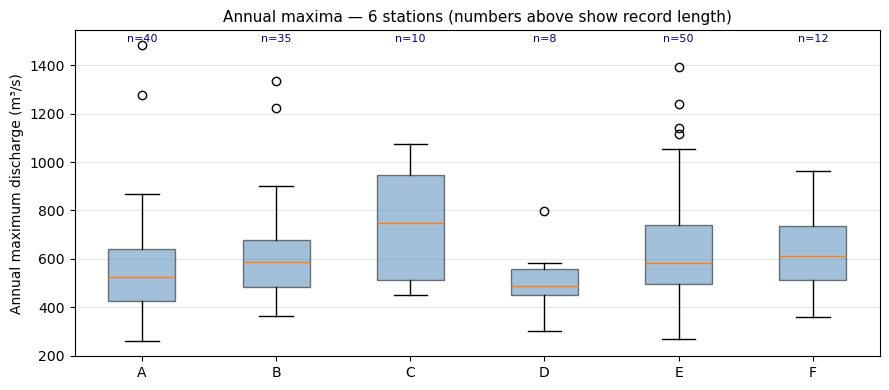

In [4]:
# Box plots give a quick visual check: short-record stations (C, D, F)
# tend to have higher apparent spread simply because they have fewer points,
# not because they are more variable — the hierarchical model accounts for this.
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(
    [data_dict[n] for n in stations],
    tick_labels=list(stations.keys()),   # tick_labels avoids DeprecationWarning in mpl ≥ 3.9
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)
ax.set_ylabel("Annual maximum discharge (m³/s)")
ax.set_title("Annual maxima — 6 stations (numbers above show record length)", fontsize=11)

# Annotate record length above each box to link sample size to apparent spread
for i, (n, p) in enumerate(stations.items(), start=1):
    ax.text(i, ax.get_ylim()[1] * 0.97, f"n={p['n']}", ha="center", fontsize=8, color="navy")

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


---
## 1. Fit the hierarchical model

In [5]:
model = HierarchicalGEV(
    T_values=[2, 5, 10, 25, 50, 100, 200, 500],
    n_chains=2,       # 4 chains for production; 2 here for speed
    n_samples=500,    # 1000 for production
    warmup=500,
)

# Run MCMC — compiles and samples the Stan model
model.fit(data_dict)
print("Sampling complete.")


Building...

In file included from /Users/salvadornavasfernandez/Library/Caches/httpstan/4.13.0/models/qdfuhjrs/model_qdfuhjrs.cpp:2:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/model/model_header.hpp:4:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math.hpp:19:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:4:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math/prim/fun/Eigen.hpp:23:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/Eigen/Sparse:26:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/Eigen/SparseCore:61:
/opt/anaconda3/lib/python3.12/site-packages/httpstan/include/Eigen/src/SparseCore/TriangularSolver.h:273:13: warning: variable 'count' set but not used [-Wunused-but-set-variable]
  273 |       Index count = 0;
      |             ^
In file

In file included from /Users/salvadornavasfernandez/Library/Caches/httpstan/4.13.0/models/qdfuhjrs/model_qdfuhjrs.cpp:2:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/model/model_header.hpp:4:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math.hpp:19:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:12:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math/rev/fun.hpp:56:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math/rev/fun/elt_multiply.hpp:9:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math/rev/fun/multiply.hpp:7:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math/prim/fun.hpp:35:
In file included from /opt/anaconda3/lib/python3.12/site-packages/httpstan/include/stan/math/prim/fun/

5 warnings generated.
ld: warning: duplicate -rpath '/opt/anaconda3/lib' ignored
ld: warning: object file (/opt/anaconda3/lib/python3.12/site-packages/httpstan/stan_services.o) was built for newer 'macOS' version (15.0) than being linked (11.1)



Building: 6.5s, done.

...

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:


  Exception: model_qdfuhjrs_namespace::log_prob: xi_station[3] is 1.08503, but must be less than or equal to 1.000000 (in '/var/folders/44/dw7p6q9108xcc4mmh_f7q1vc0000gn/T/httpstan_ezmmgu2g/model_qdfuhjrs.stan', line 27, column 4 to column 53)


  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,


  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.


Sampling complete.


In [6]:
posterior_df = model.posterior_summary()

print("Population parameters (true: mu=500, sigma=150, xi=0.12):")
print(posterior_df.loc[["mu_pop", "sigma_pop", "xi_pop"]].round(2))

print("\nHyperprior scales:")
print(posterior_df.loc[["tau_mu", "tau_sigma", "tau_xi"]].round(3))


Population parameters (true: mu=500, sigma=150, xi=0.12):
             mean    std    q2.5   q97.5
mu_pop     514.82  25.07  462.25  564.26
sigma_pop  163.78  16.98  132.09  199.40
xi_pop       0.09   0.08   -0.05    0.27

Hyperprior scales:
             mean     std   q2.5    q97.5
tau_mu     43.356  32.161  3.076  116.895
tau_sigma   0.134   0.139  0.003    0.460
tau_xi      0.074   0.070  0.002    0.248


---
## 2. Return levels with credible intervals

In [7]:
# Posterior return levels with 90 % credible interval
demo_rl = model.return_levels(credible=0.90)

medians_100 = demo_rl["T100_median"].values
lowers_100  = demo_rl["T100_lower"].values
uppers_100  = demo_rl["T100_upper"].values

T_vals = [2, 5, 10, 25, 50, 100, 200, 500]
print("Return level medians (m³/s):")
print(demo_rl[[f"T{T}_median" for T in T_vals]].rename(
    columns={f"T{T}_median": f"T{T}" for T in T_vals}).round(0))


Return level medians (m³/s):
      T2     T5    T10     T25     T50    T100    T200    T500
A  545.0  749.0  896.0  1095.0  1257.0  1429.0  1607.0  1852.0
B  584.0  780.0  922.0  1118.0  1270.0  1432.0  1609.0  1859.0
C  601.0  810.0  963.0  1171.0  1335.0  1509.0  1692.0  1951.0
D  554.0  748.0  885.0  1073.0  1224.0  1377.0  1543.0  1771.0
E  580.0  789.0  938.0  1141.0  1303.0  1469.0  1644.0  1896.0
F  585.0  783.0  922.0  1113.0  1262.0  1419.0  1582.0  1806.0


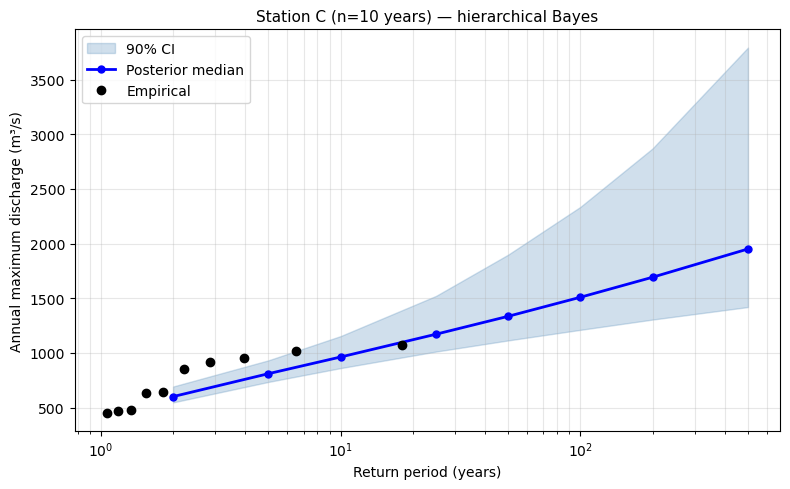

In [8]:
# Return level plot for a single station with the 90 % credible interval.
# Station C is chosen because it has the shortest record (n=10), so the
# hierarchical prior exerts the largest regularising effect here.
station_plot = "C"
medians = demo_rl.loc[station_plot, [f"T{T}_median" for T in T_vals]].values
lowers  = demo_rl.loc[station_plot, [f"T{T}_lower"  for T in T_vals]].values
uppers  = demo_rl.loc[station_plot, [f"T{T}_upper"  for T in T_vals]].values

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(T_vals, lowers, uppers, alpha=0.25, color="steelblue", label="90% CI")
ax.semilogx(T_vals, medians, "b-o", lw=2, ms=5, label="Posterior median")

# Empirical plotting positions (Gringorten formula): F = (i - 0.44) / (n + 0.12)
# Gringorten constants reduce bias for GEV-distributed data compared to Weibull (i/n+1).
data_s = np.sort(data_dict[station_plot])
n_s = len(data_s)
emp_prob = (np.arange(1, n_s + 1) - 0.44) / (n_s + 0.12)
# Convert non-exceedance probability to return period T = 1 / (1 - F)
ax.semilogx(1.0 / (1.0 - emp_prob), data_s, "ko", ms=6, label="Empirical", zorder=5)

ax.set_xlabel("Return period (years)")
ax.set_ylabel("Annual maximum discharge (m³/s)")
ax.set_title(f"Station {station_plot} (n={stations[station_plot]['n']} years) — hierarchical Bayes",
             fontsize=11)
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()


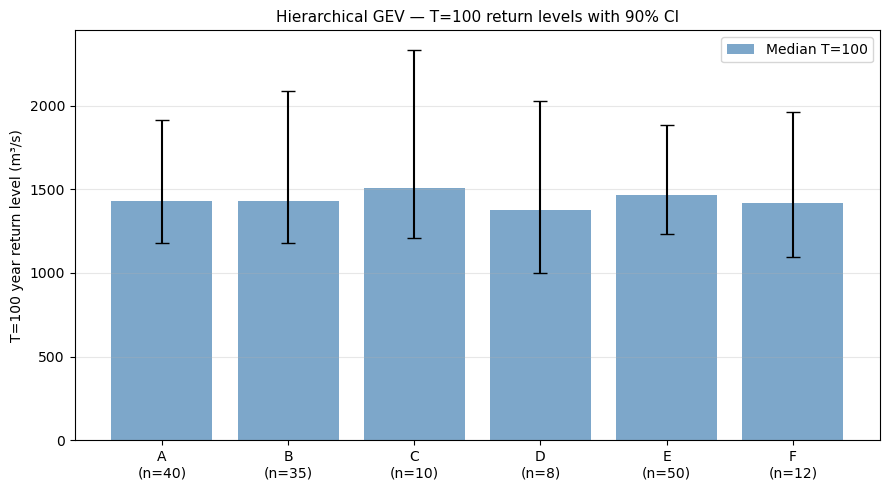

In [9]:
# T=100 return level across all stations.
# Error bars show the 90 % credible interval — shorter records have wider bars,
# directly visualising the uncertainty cost of limited data.
medians_100 = demo_rl["T100_median"].values
lowers_100  = demo_rl["T100_lower"].values
uppers_100  = demo_rl["T100_upper"].values
names       = list(stations.keys())
n_records   = [p["n"] for p in stations.values()]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(names))
ax.bar(x, medians_100, color="steelblue", alpha=0.7, label="Median T=100")

# fmt="none" separates the error bars from any marker/line,
# keeping the bar chart clean while still showing the CI.
ax.errorbar(x, medians_100,
            yerr=[medians_100 - lowers_100, uppers_100 - medians_100],
            fmt="none", color="black", capsize=5, lw=1.5)

ax.set_xticks(x)
ax.set_xticklabels([f"{n}\n(n={nr})" for n, nr in zip(names, n_records)])
ax.set_ylabel("T=100 year return level (m³/s)")
ax.set_title("Hierarchical GEV — T=100 return levels with 90% CI", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


---
## 3. Pooling benefit — short vs long records

The key advantage of the hierarchical model: stations with very few observations
(C: 10 years, D: 8 years, F: 12 years) get narrower credible intervals than
they would from an independent at-site fit.

In [10]:
from pyhydra.climate.spatial_analysis import fit_gev_mle, return_level

# At-site MLE for each station — uses bounded multi-start to avoid degenerate
# solutions (unconstrained MLE can give xi >> 1 with n < 15 observations).
T_comp = 100
atsite_rl = {}
for name, vals in data_dict.items():
    params = fit_gev_mle(vals)
    atsite_rl[name] = return_level(params, T_comp)

hier_rl  = demo_rl["T100_median"].values
hier_ci  = uppers_100 - lowers_100   # full 90 % CI width

# The table shows the pooling benefit: short-record stations (C, D, F) tend to
# have inflated at-site MLE (overfit to a single lucky/unlucky extreme) while
# the hierarchical estimate pulls them toward the regional signal.
print(f"{'Station':>8}  {'n':>4}  {'At-site MLE':>12}  {'Hier. median':>12}  {'Hier. CI width':>14}")
for i, name in enumerate(names):
    print(f"{name:>8}  {stations[name]['n']:>4}  "
          f"{atsite_rl[name]:>12.0f}  {hier_rl[i]:>12.0f}  {hier_ci[i]:>14.0f}")


 Station     n   At-site MLE  Hier. median  Hier. CI width
       A    40          1387          1429             731
       B    35          1536          1432             910
       C    10          2958          1509            1125
       D     8           886          1377            1027
       E    50          1454          1469             649
       F    12          1084          1419             866


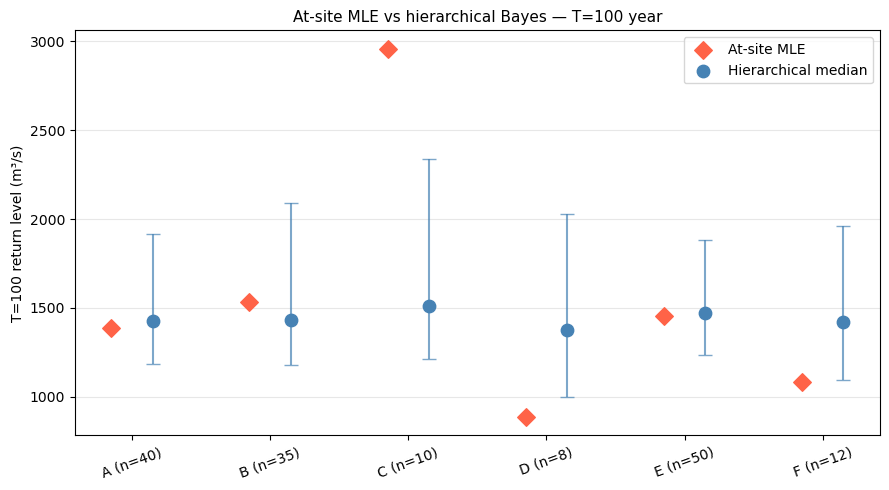

In [11]:
# Scatter plot: at-site MLE (red diamonds) vs hierarchical median (blue circles)
# with 90 % CI error bars.  The horizontal offset (±0.15) prevents overplotting
# of the two point types at the same x position.
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(names))

ax.scatter(x - 0.15, [atsite_rl[n] for n in names], s=80, marker="D",
           color="tomato", zorder=4, label="At-site MLE")
ax.scatter(x + 0.15, hier_rl, s=80, marker="o",
           color="steelblue", zorder=4, label="Hierarchical median")

# Error bars only on the hierarchical estimates — at-site MLE CIs are not shown
# here because they are typically much wider and would dominate the chart.
ax.errorbar(x + 0.15, hier_rl,
            yerr=[hier_rl - lowers_100, uppers_100 - hier_rl],
            fmt="none", color="steelblue", capsize=5, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f"{n} (n={stations[n]['n']})" for n in names], rotation=20)
ax.set_ylabel("T=100 return level (m³/s)")
ax.set_title("At-site MLE vs hierarchical Bayes — T=100 year", fontsize=11)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


---
## 4. Trace plot diagnostics (requires pystan)

After fitting, check MCMC convergence by inspecting the trace of population
parameters and R̂ (Gelman-Rubin statistic). All R̂ should be close to 1.0.

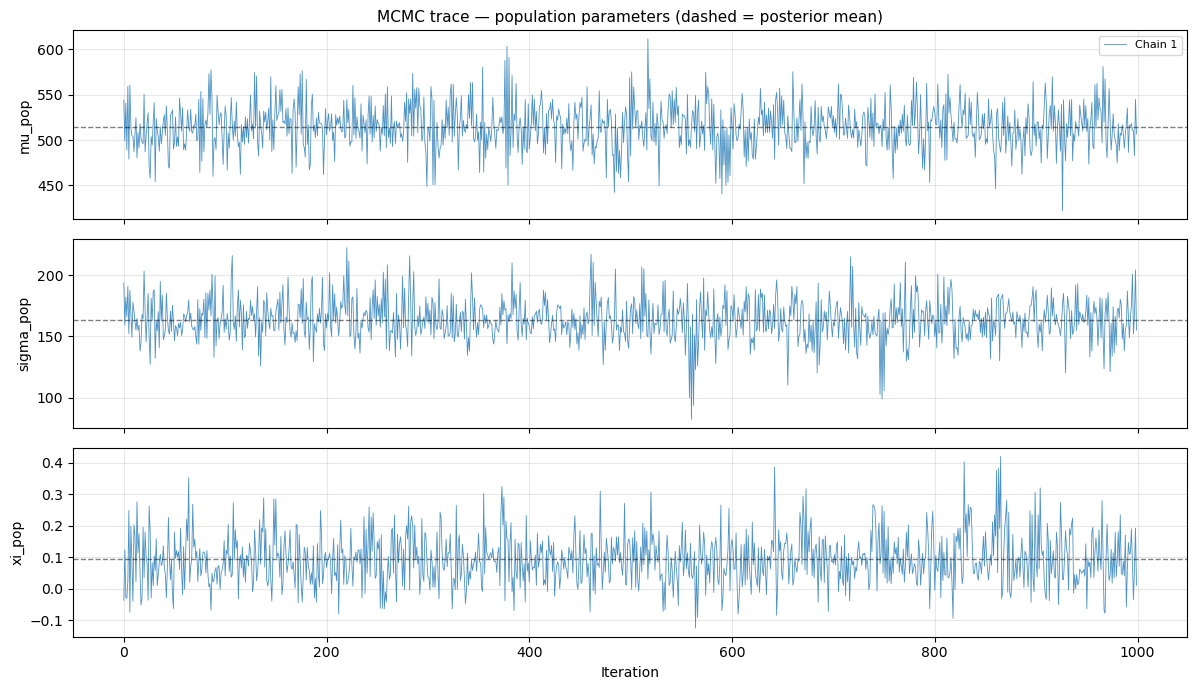

In [12]:
# MCMC trace plot — visual convergence check for population parameters.
# Well-mixed chains (no trends, all chains overlap) indicate convergence.
fit = model._fit

params_to_plot = ["mu_pop", "sigma_pop", "xi_pop"]
fig, axes = plt.subplots(len(params_to_plot), 1, figsize=(12, 7), sharex=True)

for ax, param in zip(axes, params_to_plot):
    # fit[param] shape: (n_chains, n_samples) — one line per chain
    samples = np.asarray(fit[param])
    if samples.ndim == 1:
        samples = samples[np.newaxis, :]  # handle merged-chain output
    for chain_idx in range(samples.shape[0]):
        ax.plot(samples[chain_idx], lw=0.6, alpha=0.8, label=f"Chain {chain_idx+1}")
    ax.set_ylabel(param)
    ax.axhline(np.mean(samples), color="k", ls="--", lw=1, alpha=0.5)  # posterior mean
    ax.grid(alpha=0.3)

axes[0].set_title("MCMC trace — population parameters (dashed = posterior mean)", fontsize=11)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Iteration")
plt.tight_layout()
plt.show()
